In [ ]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sn

In [ ]:
df = pd.read_csv('/content/multiclass_role_prediction_dataset.csv')

print(df.head())

   Python_Skill  ML_Skill  Networking_Skill  Cloud_Skill  SQL_Skill  \
0            68        45                80           88         57   
1            69        40                88           79         94   
2            56        54                69           76         36   
3            90         8                12           75         56   
4            85        71                42            4         79   

          Predicted_Role  
0  Cybersecurity Analyst  
1  Cybersecurity Analyst  
2        DevOps Engineer  
3          Web Developer  
4           Data Analyst  


In [ ]:
print(df.columns)

Index(['Python_Skill', 'ML_Skill', 'Networking_Skill', 'Cloud_Skill',
       'SQL_Skill', 'Predicted_Role'],
      dtype='object')


In [ ]:
X = df[[
    'Python_Skill',
    'ML_Skill',
    'Networking_Skill',
    'Cloud_Skill',
    'SQL_Skill'
]]

In [ ]:
y = df['Predicted_Role']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

In [ ]:
print(len(X_train))

print(len(X_test))

96
24


In [ ]:
model = LogisticRegression(max_iter=1000)

In [11]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [12]:
accuracy = model.score(X_test, y_test)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.875


In [13]:
model.predict(X_test[0:5])

array(['ML Engineer', 'ML Engineer', 'Data Analyst',
       'Cybersecurity Analyst', 'Web Developer'], dtype=object)

In [14]:
y_test.iloc[0:5]

,Predicted_Role
45,ML Engineer
79,ML Engineer
56,Data Analyst
85,Cybersecurity Analyst
99,Web Developer


In [16]:
y_predicted = model.predict(X_test)

In [17]:
cm = confusion_matrix(y_test, y_predicted)

print(cm)

[[3 0 0 0 0]
 [0 4 0 0 1]
 [0 0 3 0 1]
 [0 0 0 5 0]
 [1 0 0 0 6]]


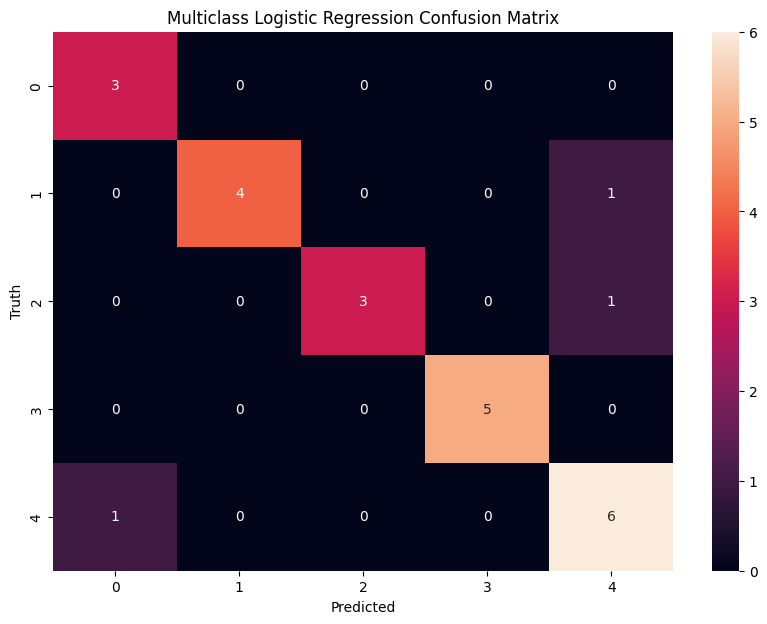

In [18]:
plt.figure(figsize=(10,7))

sn.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')

plt.ylabel('Truth')

plt.title('Multiclass Logistic Regression Confusion Matrix')

plt.show()

In [19]:
new_student = [[85, 90, 20, 30, 75]]

prediction = model.predict(new_student)

print("Predicted Role:")

print(prediction)

Predicted Role:
['ML Engineer']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
